# Introduction

Nama    : Austin Silitonga

Batch   : HCK-037

# Problem Statement & Dataset Description

### Case

Pak Andreas adalah pria yang berusia 40 tahun yang sudah berkeluarga dan mempunyai 2 orang anak. Ia ingin pindah dan membeli rumah di Northeast States, USA. Untuk saat ini ia sudah memiliki tabungan untuk membeli rumah sebesar 2.000.000 dollar, Pak Andreas sudah memiliki datanya beberapa tetapi ia takut salah ambil keputusan terkait rumah yang akan ia beli karena harganya juga tidak murah. Oleh karena itu, dia membutuhkan bantuan untuk menemukan rumah yang sesuai dengan budget dan keadaannya saat ini.

### SMART

Specific : Analisis harga rumah di Northeast States, Usa untuk Pak Andreas yang sudah memiliki keluarga dan 2 anak

Measurable : Mengukur distribusi dan rata-rata harga rumah di Northeast States

Achiveable : Dataset dari Pak Andreas terkait harga-harga rumah di Northeast States

Relevant : Penting untuk Pak Andreas mengambil keputusan dalam membeli rumah sesuai budget yaitu 2.000.000 dollar

Time-bound : 1 minggu

### Problem Statement

Mengukur distribusi dan rata-rata harga rumah di Northeast States melalui dataset yang diberikan oleh Pak Andreas dengan tujuan untuk mengambil keputusan dalam membeli rumah sesuai dengan budget yaitu 2.000.000 USD dan keadaan Pak Andreas yang sudah berkeluarga dan memiliki 2 anak dalam kurun waktu seminggu.

### Penjabaran Masalah

Penjabaran masalah menggunakan metode 5w + 1h :

1. Bagaimana distribusi harga rumah di Northeast States?
2. Berapa jumlah outlier dalam dataset rumah di Northeast States?
3. Berapakah persentase harga rumah senilai 2.000.000 USD pada dataset yang sudah di handling outliernya?
4. Berapa rata-rata harga pasaran rumah di Northeast States?
5. Apakah rumah dalam rentang budget 2.000.000 USD masih cukup untuk keluarga 4 orang??
6. Apakah jumlah lantai rumah berpengaruh terhadap harga rumah dalam rentang budget 2.000.000 USD? 

### Deskripsi Dataset

Dataset ini diambil Kaggle.com, yang dimana memiliki 13 kolom terdiri :

**Price**                : Harga rumah

**Area**                 : Luas wilayah rumah

**Bedrooms**             : Jumlah Kamar Tidur

**Bathrooms**            : Jumlah Kamar Mandi

**Stories**              : Jumlah tingkatan lantai rumah

**Mainroad**             : Posisi rumah berada di jalan utama

**Guestroom**            : Jumlah kamar khusus untuk tamu atau kerabat

**Basement**             : Rumah tersebut memiliki ruang bawah tanah

**Hotwaterheating**      : Rumah tersebut memiliki fasilitas pemanas air

**Airconditioning**      : Rumah tersebut memiliki fasilitas pengatur suhu ruangan

**Parking**              : Jumlah tempat parkir

**Prefarea**             : Rumah tersebut berada diarea pilihan

**Furnishing Status**    : Rumah tersebut memiliki perabotan atau tidak 

https://public.tableau.com/views/Book1_17702241751660/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

# Data Loading

Langkah pertama kita akan melakukan loading data dari dataset yang sudah kita punya. Kita juga akan eksplor singkat terkait data yang dipunya, untuk mengetahui langkah yang akan dilakukan selanjutnya.

In [106]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [28]:
df = pd.read_csv('Housing.csv')

df.head(11)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [30]:
df.duplicated().sum()

0

In [31]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Dari hasil eksplorasi singkat, dapat kita lihat bahwa dataset yang dimiliki sudah bersih, tidak ada missing value, dan juga kolom berisikan data numerik memiliki tipe kolom yang sesuai. Oleh karena itu, langkah data cleaning dapat kita lewati, dan menuju ke eksplorasi data analis untuk menganalisa data lebih dalam sesuai dengan tujuan awal.

# Exploration Data Analysis

Tujuan awal dari analisis ini adalah untuk memberi bantuan dalam pengambilan keputusan Pak Andreas saat membeli rumah di Northeast States, yang dimana sesuai dengan budget yaitu 2.000.000 USD dan diketahui bahwa Pak Andreas sudah berkeluarga dengan memiliki 2 anak. Dari case ini kita dapat kategorikan client sebagai seorang 'Family Buyer', yang dimana membeli rumah untuk kenyamanan bagi keluarganya. Oleh karena itu variabel utama yang perlu kita analisis sudah pastinya adalah harga rumah, luas wilayah rumah tersebut, jumlah dari kamar tidur dan kamar mandi dan juga jumlah lantai untuk menentukan kelayakan rumah bagi keluarga dengan dua anak.

Langkah pertama dalam eksplorasi analisis data, perlu kita ketahui terlebih dahulu distribusi harga dari dataset harga rumah di Northeast States. Kita akan mencari rata-rata dan mediannya, lalu melihat nilai skewnessnya terlebih dahulu untuk mengetahui kecondongan data kearah mana.

In [45]:
mean = df['price'].mean()
median = df['price'].median()
modus = df['price'].mode()[0]

print(f'rata-rata harga rumah di Northeast States : {mean:.2f} USD')
print(f'median harga rumah di Northeast States : {median} USD')
print(f'modus harga rumah di Northeast States : {modus} USD')

rata-rata harga rumah di Northeast States : 4766729.25 USD
median harga rumah di Northeast States : 4340000.0 USD
modus harga rumah di Northeast States : 3500000 USD


In [33]:
skew = df['price'].skew()
kurt = df['price'].kurt()
print(f'nilai skewness dari harga rumah di Northeast States : {skew:.2f}')
print(f'nilai kurtosis dari harga rumah di Northeast States : {kurt:.2f}')


nilai skewness dari harga rumah di Northeast States : 1.21
nilai kurtosis dari harga rumah di Northeast States : 1.96


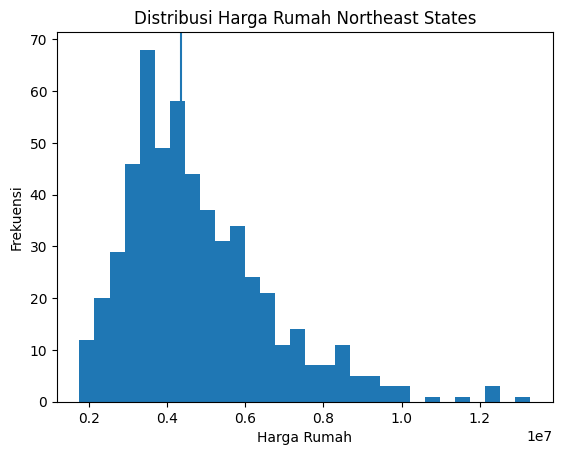

In [44]:
plt.hist(df["price"], bins=30)

# Menambahkan garis median
plt.axvline(median)

# Memberi label dan judul
plt.xlabel("Harga Rumah")
plt.ylabel("Frekuensi")
plt.title("Distribusi Harga Rumah Northeast States")

# Menampilkan grafik
plt.show()

Dari perhitungan dan histogram diatas, dapat kita ketahui bahwa distribusi harga rumah di Northeast States menunjukkan kecondongan ke arah Positive Skew atau Right Skewed. Sebagian besar rumah berada pada rentang harga rendah hingga menengah, sementara sebagian kecil rumah memiliki harga sangat tinggi. Hal ini terlihat dari histogram yang memiliki ekor panjang kearah kanan, mengindikasikan adanya outlier pada harga rumah yang lebih mahal. Selanjutnya kita akan menganalisa berapa jumlah outlier yang dimiliki oleh dataset rumah di Northeast States

Dikarenakan nilai skewness > 0,5, kita akan menggunakan metode Tukey's rule untuk menentukan upper boundary dan lower boundary sebagai alat ukur menentukan outlier.

In [55]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
IQR = q3 - q1

upper = q3 + (1.5*IQR)
lower = q1 - (1.5*IQR)

print(f'nilai upper boundary : {upper} USD, \nnilai lower boundary : {lower} USD')

outlier = df[(df['price']>upper) | (df['price']< lower)]
no_outlier = df[(df['price']<=upper) & (df['price']>= lower)]

nilai upper boundary : 9205000.0 USD, 
nilai lower boundary : -35000.0 USD


In [54]:
jumlah = outlier.shape[0]

print(f'jumlah outlier dalam dataset rumah di Northeast States adalah {jumlah} data')

jumlah outlier dalam dataset rumah di Northeast States adalah 15 data


In [66]:
outlier.sort_values('price', ascending=False)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Terdapat 15 data outlier yang berada pada dataset ini yang dimana harga tertinggi sebesar 13.300.000 USD.

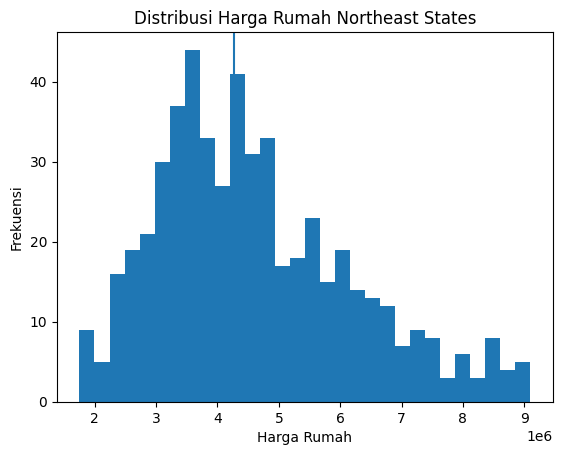

In [ ]:
plt.hist(no_outlier['price'], bins=30)
plt.axvline(no_outlier['price'].median())
plt.xlabel("Harga Rumah")
plt.ylabel("Frekuensi")
plt.title("Distribusi Harga Rumah Northeast States")
plt.show()

In [64]:
no_outlier['price'].skew()

0.6957546545878598

Perubahan bentuk histogram kepada data yang telah di bersihkan dari nilai outliernya menunjukkan bahwa adanya perubahan kecondongan dari yang sebelumnya sangat condong ke arah kanan, menjadi sedang, hasil ini dicerminkan dari nilai skewnes yang berada diantara 0.5 dan 1.

Setelah kita mengetahui distribusi harga rumah yang condong kearah Right Skewed dan outlier telah di handling, sekarang kita akan menganalisa ada berapa persen rumah yang memiliki harga sesuai dengan budget yang dimiliki oleh Pak Andreas, karena tujuan dari analisis ini adalah mencarikan rumah yang memiliki harga sesuai dengan budget Pak Andreas, yaitu sekitar 2.000.000 USD.

In [69]:
rumah = df[df['price']<= 2000000]
persen = len(rumah)/len(no_outlier)*100

print(f'rumah dengan harga sekitar 2.000.000 USD ada {persen:.1f}%')

rumah dengan harga sekitar 2.000.000 USD ada 1.7%


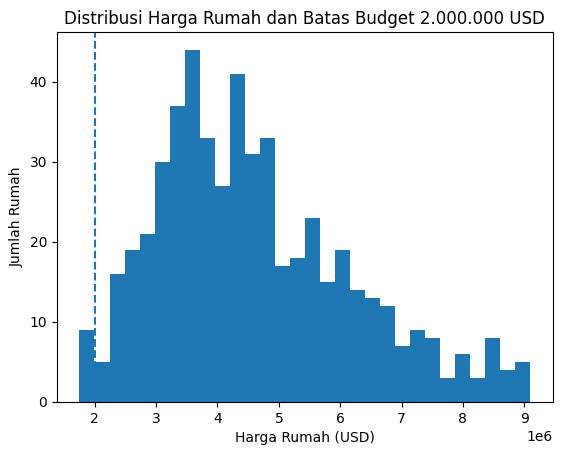

In [ ]:
plt.hist(no_outlier['price'], bins=30)
plt.axvline(2000000, linestyle='--')
plt.title('Distribusi Harga Rumah dan Batas Budget 2.000.000 USD')
plt.xlabel('Harga Rumah (USD)')
plt.ylabel('Jumlah Rumah')
plt.show()

Berdasarkan histogram distribusi harga rumah yang sudah dihandling dari outlier, terlihat bahwa sebagian besar harga rumah berada disebelah kanan garis batas budget yaitu sebesar 2.000.000 USD. Hal ini menunjukkan bahwa secara umum, dataset mencerminkan kondisi pasar rumah di Northeast States yang relatif mahal. Hasil dari tampilan histogram juga sebanding dengan hasil persentase dari rumah yang memiliki harga sekitar 2.000.000 USD yaitu 1.7% dari total dataset.

Kita ketahui bahwa dari dataset yang kita punya kalau harga rumah di Northeast States relatif mahal dan diluar dari budget Pak Andreas. Selanjutnya untuk tambahan kita akan melihat harga pasar rumah di Northeast States menggunakan metode Confidence Interval.

In [75]:
n = len(no_outlier)
stdharga = no_outlier['price'].std(ddof=1)
alpha = 0.05

se = stdharga / (n**0.5)
t_value = stats.t.ppf(1-alpha/2, df=n-1)

upper = mean + t_value * se
lower = mean - t_value * se

print(f'Confidence Interval harga rumah di Northeast State dengan confidence level 95% adalah \nantara {lower:.2f} USD hingga {upper:.2f} USD')

Confidence Interval harga rumah di Northeast State dengan confidence level 95% adalah 
antara 4630531.40 USD hingga 4902927.10 USD


Berdasarkan hasil perhitungan confidence interval dengan confidence level 95%, rata-rata harga rumah di Northeast States diperkirakan berada pada rentang 4.630.531 USD hingga 4.902.927 USD. Hal ini menunjukkan bahwa secara umum harga pasaran rumah di wilayah tersebut berada jauh di atas budget yang dimiliki oleh Pak Andreas, sehingga pembelian rumah dengan budget 2.000.000 USD hanya memungkinkan pada beberapa rumah tertentu.

Kita ketahui bahwa tujuan awal adalah untuk membantu pengambilan keputusan Pak Andreas dalam membeli rumah sekalipun budget yang dimiliki jauh dari harga pasar rumah di Northeast States. Kita bisa lanjutkan dengan memfilter dataset sesuai dengan budget yang dimiliki oleh Pak Andreas, yang dimana tujuan kita saat ini adalah untuk melihat apakah rumah dengan harga 2.000.000 USD di Northeast States cukup untuk 4 orang.

In [76]:
df_budget = no_outlier[no_outlier['price']<= 2000000]

In [77]:
df_budget

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


Kita ketahui bahwa untuk dapat dikatakan rumah itu cukup harus berdasarkan indikator, yang dimana Pak Andreas adalah seorang yang sudah berkeluarga dan memiliki 2 anak. Oleh karena itu indikator yang perlu kita lihat selain harga, saat ini adalah rumah dengan jumlah kamar tidur >= 3 ruang dan kamar mandi >= 2 ruang.

In [96]:
KT = df_budget[df_budget['bedrooms'] >= 3]
persentidur = len(KT) / len(df_budget) * 100

print(f'persentase jumlah kamar tidur sebanyak 3 ruangan adalah {persentidur:.1f}%')

persentase jumlah kamar tidur sebanyak 3 ruangan adalah 55.6%


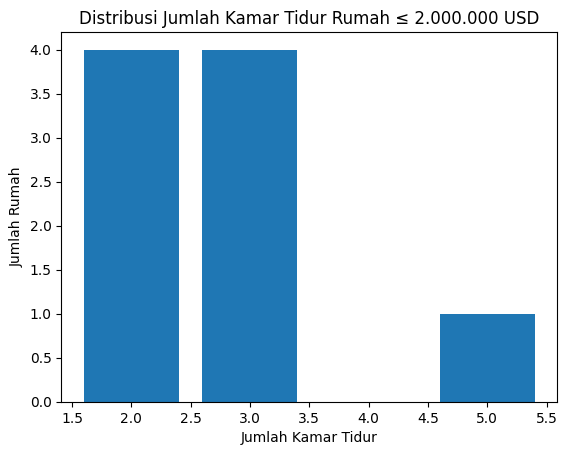

In [97]:
KT_counts = df_budget['bedrooms'].value_counts().sort_index()

plt.figure()
plt.bar(KT_counts.index, KT_counts.values)
plt.title('Distribusi Jumlah Kamar Tidur Rumah ≤ 2.000.000 USD')
plt.xlabel('Jumlah Kamar Tidur')
plt.ylabel('Jumlah Rumah')
plt.show()

In [100]:
KM = df_budget[df_budget['bathrooms'] >= 2]
persenmandi = len(KM) / len(df_budget) * 100
print(f'persentase jumlah kamar mandi sebanyak 2 ruangan adalah {persenmandi:.1f}%')

persentase jumlah kamar mandi sebanyak 2 ruangan adalah 0.0%


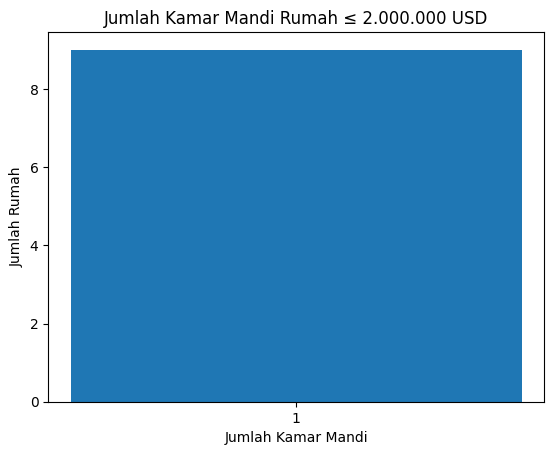

In [101]:
KM_counts = df_budget['bathrooms'].value_counts()

plt.figure()
plt.bar(KM_counts.index.astype(str), KM_counts.values)
plt.title('Jumlah Kamar Mandi Rumah ≤ 2.000.000 USD')
plt.xlabel('Jumlah Kamar Mandi')
plt.ylabel('Jumlah Rumah')
plt.show()

Berdasarkan hasil analisis rumah dengan harga di bawah atau sama dengan 2.000.000 USD, sebagian rumah masih memiliki jumlah kamar tidur yang memadai untuk keluarga beranggotakan empat orang, memiliki keterbatasan fasilitas kamar mandi, di mana seluruh rumah hanya menyediakan satu kamar mandi. Hal ini menjadi pertimbangan penting bagi Pak Andreas dalam menentukan prioritas antara keterjangkauan harga dan kenyamanan keluarga.

Langkah selanjutnya adalah kita akan melihat apakah jumlah tingkatan lantai mempengaruhi harga rumah. Dikarenakan yang kita uji hanyalah kolom 'stories' terhadap 'price', kita menggunakan metode one-way anova.

In [109]:
price_by_stories = [
    group['price'].values
    for i, group in df_budget.groupby('stories')]

In [114]:
f_stat, p_value = f_oneway(*price_by_stories)

f_stat, p_value

print(f'f-statistik: {f_stat:.4f}')
print(f'p-value: {p_value}')

f-statistik: 1.3058
p-value: 0.290729291435134


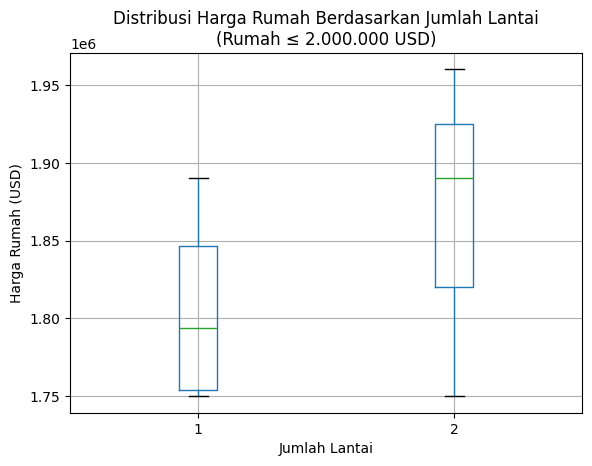

In [116]:
df_budget.boxplot(column='price', by='stories')
plt.title('Distribusi Harga Rumah Berdasarkan Jumlah Lantai\n(Rumah ≤ 2.000.000 USD)')
plt.suptitle('')  # menghapus judul default
plt.xlabel('Jumlah Lantai')
plt.ylabel('Harga Rumah (USD)')
plt.show()

Hasil uji one-way anova menunjukkan bahwa terdapat perbedaan rata-rata harga rumah yang signifikan berdasarkan jumlah lantai dalam rentang budget 2.000.000 USD (p-value < 0.05). Hal ini mengindikasikan bahwa jumlah lantai memiliki pengaruh terhadap harga rumah. Dapat kita lihat hasil box plot, rumah dengan 2 lantai dalam rentang harga ≤ 2.000.000 USD cenderung memiliki harga yang lebih tinggi dibandingkan rumah 1 lantai. Hal ini menunjukkan bahwa jumlah lantai berpengaruh terhadap harga rumah, bahkan dalam batas budget yang sama.

# Conclusion

Dari hasil analisis kita dapat mengetahui bahwa rumah dengan harga mendekati atau di bawah 2.000.000 USD hanya mencakup sekitar 1–2% dari total dataset setelah penanganan outlier. Hal ini mengindikasikan bahwa opsi rumah yang sesuai dengan budget Pak Andreas tergolong terbatas. Karena pasar rumah di wilayah Northeast States ini cenderung memiliki harga yang relatif mahal.

Secara keseluruhan, rumah dengan budget 2.000.000 USD masih memungkinkan untuk keluarga dengan 4 anggota, namun dengan kompromi pada ukuran dan fasilitas rumah. Oleh karena itu, Pak Andreas disarankan untuk memfokuskan pencarian pada rumah 1 lantai, memprioritaskan aspek utama seperti jumlah kamar tidur dan luas wilayah, serta mempertimbangkan lokasi atau area yang tidak termasuk segmen harga premium.